In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

**Data Laoding**

In [2]:
# Define classes and their labels
classes = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}

# Load and preprocess the dataset
X = []
Y = []
for cls, label in classes.items():
    pth = f"/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/{cls}"
 
    # for filename in os.listdir(pth):
    for filename in sorted(os.listdir(pth)):
        img = cv2.imread(os.path.join(pth, filename), 0)
        img = cv2.resize(img, (200, 200))
        X.append(img.flatten() / 255.0)  # Flatten and normalize the image data
        Y.append(label)
X = np.array(X)
Y = np.array(Y)

**Splitting the data**

In [3]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, random_state=50, test_size=0.2)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier
sv = SVC()
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9695121951219512
Testing Score: 0.837979094076655


**Metrics**

In [4]:
# Predictions
ytrain_pred = sv.predict(pca_train)
ytest_pred = sv.predict(pca_test)

# =========================
# TRAINING METRICS
# =========================

train_accuracy = accuracy_score(ytrain, ytrain_pred)

train_f1 = f1_score(ytrain, ytrain_pred, average='weighted')

train_sensitivity = recall_score(ytrain, ytrain_pred, average='weighted')

# Training Specificity
cm_train = confusion_matrix(ytrain, ytrain_pred)

train_specificity_list = []

for i in range(len(cm_train)):

    TP = cm_train[i, i]

    FN = np.sum(cm_train[i, :]) - TP

    FP = np.sum(cm_train[:, i]) - TP

    TN = np.sum(cm_train) - (TP + FN + FP)

    specificity = TN / (TN + FP)

    train_specificity_list.append(specificity)

train_specificity = np.mean(train_specificity_list)

# =========================
# TESTING METRICS
# =========================

test_accuracy = accuracy_score(ytest, ytest_pred)

test_f1 = f1_score(ytest, ytest_pred, average='weighted')

test_sensitivity = recall_score(ytest, ytest_pred, average='weighted')

# Testing Specificity
cm_test = confusion_matrix(ytest, ytest_pred)

test_specificity_list = []

for i in range(len(cm_test)):

    TP = cm_test[i, i]

    FN = np.sum(cm_test[i, :]) - TP

    FP = np.sum(cm_test[:, i]) - TP

    TN = np.sum(cm_test) - (TP + FN + FP)

    specificity = TN / (TN + FP)

    test_specificity_list.append(specificity)

test_specificity = np.mean(test_specificity_list)

# =========================
# PRINT RESULTS
# =========================

print("========== TRAINING METRICS ==========")

print("Training Accuracy   :", train_accuracy)

print("Training F1 Score   :", train_f1)

print("Training Sensitivity:", train_sensitivity)

print("Training Specificity:", train_specificity)


print("\n========== TESTING METRICS ==========")

print("Testing Accuracy    :", test_accuracy)

print("Testing F1 Score    :", test_f1)

print("Testing Sensitivity :", test_sensitivity)

print("Testing Specificity :", test_specificity)

========== TRAINING METRICS ==========
Training Accuracy   : 0.9695121951219512
Training F1 Score   : 0.9695376329088762
Training Sensitivity: 0.9695121951219512
Training Specificity: 0.9894099000943013

========== TESTING METRICS ==========
Testing Accuracy    : 0.837979094076655
Testing F1 Score    : 0.8364105235774054
Testing Sensitivity : 0.837979094076655
Testing Specificity : 0.9442961507254141


**Visualizations**

In [5]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM
        
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

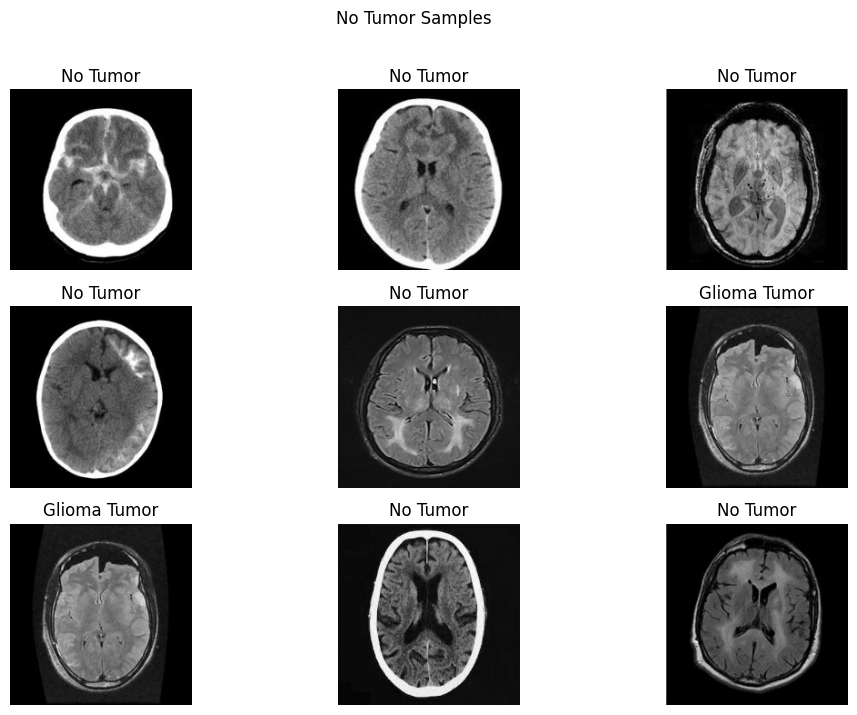

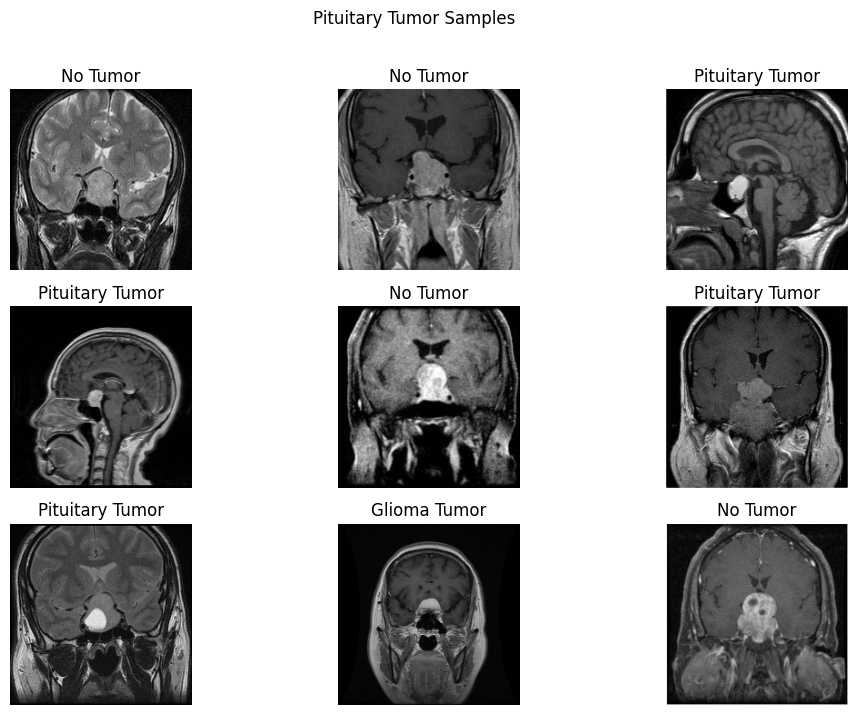

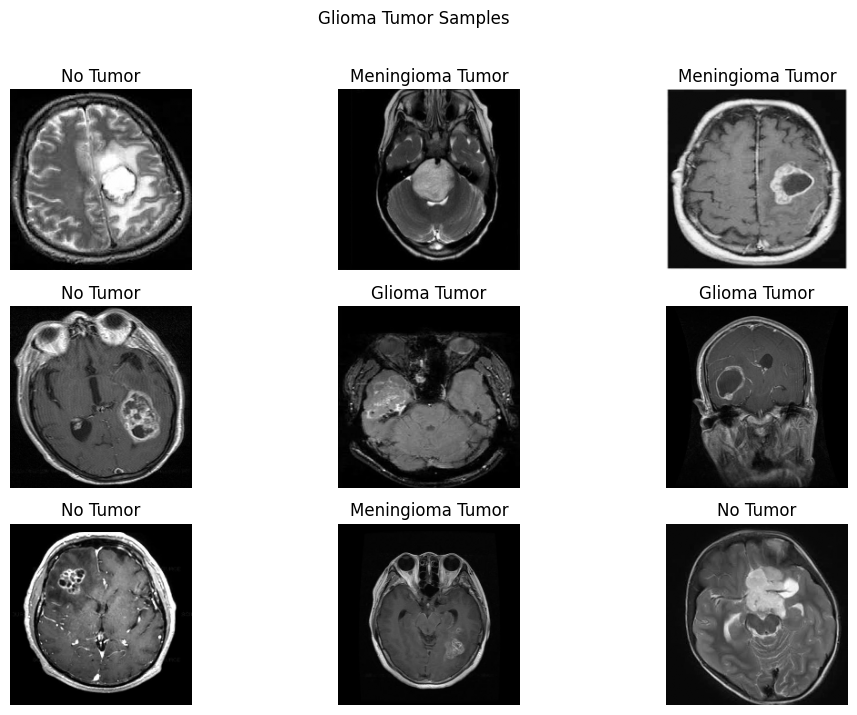

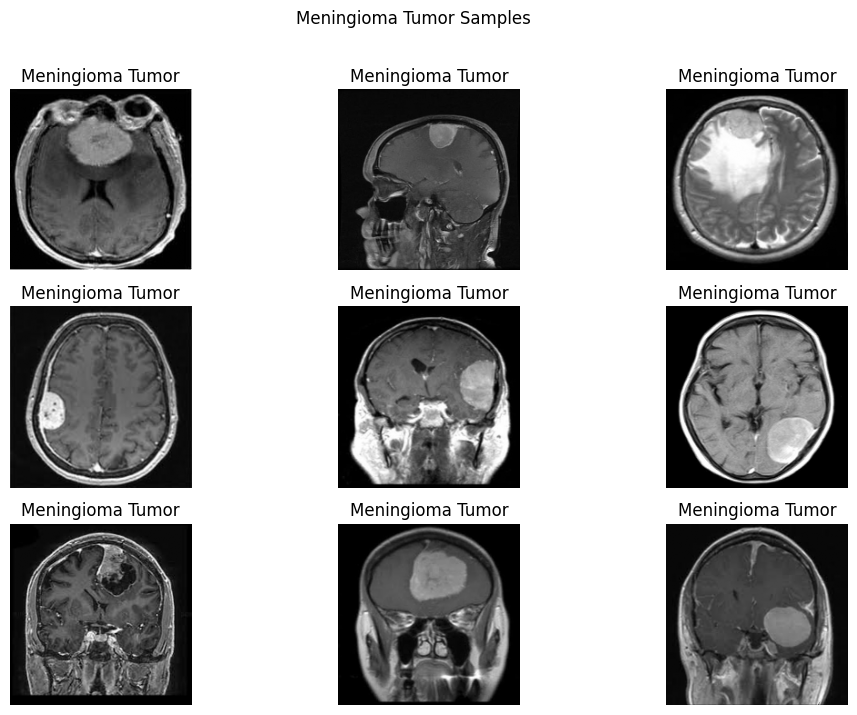

In [6]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}
# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = f"/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/{tumor_folder}"
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [7]:
import pandas as pd

# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m") 
display(styled_table)


Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


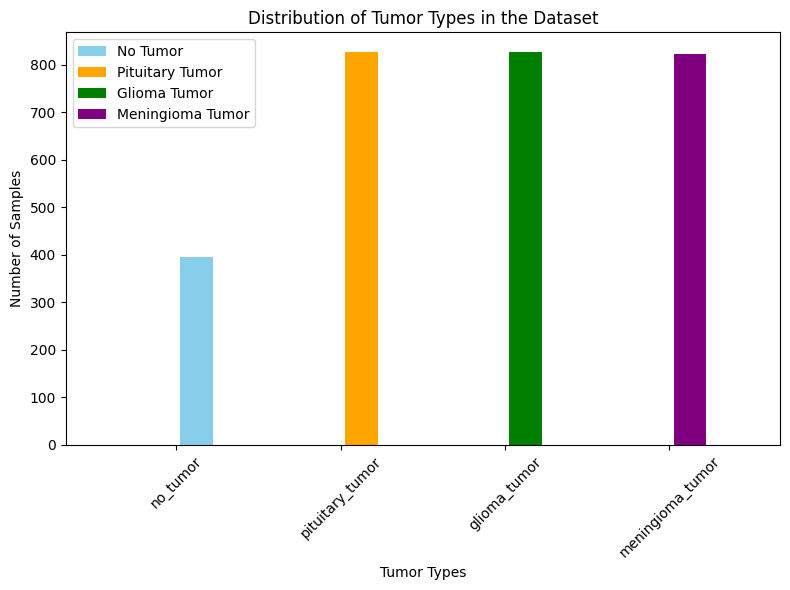

In [8]:

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show() 

Linear SVM kernel


In [9]:
# Train Support Vector Classifier
sv_linear = SVC(kernel = 'linear')
sv_linear.fit(pca_train, ytrain)


SVC(kernel='linear')

In [10]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

import numpy as np

# Predictions
ytrain_pred_linear = sv_linear.predict(pca_train)
ytest_pred_linear = sv_linear.predict(pca_test)

# =========================
# TRAINING METRICS
# =========================

train_accuracy_linear = accuracy_score(ytrain, ytrain_pred_linear)

train_f1_linear = f1_score(ytrain, ytrain_pred_linear, average='weighted')

train_sensitivity_linear = recall_score(ytrain, ytrain_pred_linear, average='weighted')

# Training Specificity
cm_train_linear = confusion_matrix(ytrain, ytrain_pred_linear)

train_specificity_list_linear = []

for i in range(len(cm_train_linear)):

    TP = cm_train_linear[i, i]

    FN = np.sum(cm_train_linear[i, :]) - TP

    FP = np.sum(cm_train_linear[:, i]) - TP

    TN = np.sum(cm_train_linear) - (TP + FN + FP)

    specificity = TN / (TN + FP)

    train_specificity_list_linear.append(specificity)

train_specificity_linear = np.mean(train_specificity_list_linear)

# =========================
# TESTING METRICS
# =========================

test_accuracy_linear = accuracy_score(ytest, ytest_pred_linear)

test_f1_linear = f1_score(ytest, ytest_pred_linear, average='weighted')

test_sensitivity_linear = recall_score(ytest, ytest_pred_linear, average='weighted')

# Testing Specificity
cm_test_linear = confusion_matrix(ytest, ytest_pred_linear)

test_specificity_list_linear = []

for i in range(len(cm_test_linear)):

    TP = cm_test_linear[i, i]

    FN = np.sum(cm_test_linear[i, :]) - TP

    FP = np.sum(cm_test_linear[:, i]) - TP

    TN = np.sum(cm_test_linear) - (TP + FN + FP)

    specificity = TN / (TN + FP)

    test_specificity_list_linear.append(specificity)

test_specificity_linear = np.mean(test_specificity_list_linear)

# =========================
# PRINT RESULTS
# =========================

print("========== LINEAR SVM TRAINING METRICS ==========")

print("Training Accuracy   :", train_accuracy_linear)

print("Training F1 Score   :", train_f1_linear)

print("Training Sensitivity:", train_sensitivity_linear)

print("Training Specificity:", train_specificity_linear)


print("\n========== LINEAR SVM TESTING METRICS ==========")

print("Testing Accuracy    :", test_accuracy_linear)

print("Testing F1 Score    :", test_f1_linear)

print("Testing Sensitivity :", test_sensitivity_linear)

print("Testing Specificity :", test_specificity_linear)

========== LINEAR SVM TRAINING METRICS ==========
Training Accuracy   : 1.0
Training F1 Score   : 1.0
Training Sensitivity: 1.0
Training Specificity: 1.0

========== LINEAR SVM TESTING METRICS ==========
Testing Accuracy    : 0.8101045296167247
Testing F1 Score    : 0.8085144319597559
Testing Sensitivity : 0.8101045296167247
Testing Specificity : 0.9345384060878927


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)


import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Training percentages
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]



rbf_accuracy = []
linear_accuracy = []

rbf_f1 = []
linear_f1 = []

rbf_sensitivity = []
linear_sensitivity = []

rbf_specificity = []
linear_specificity = []


**Comparison Results**

In [13]:

for frac in fractions:

    n_samples = int(len(pca_train) * frac)

    X_subset = pca_train[:n_samples]
    y_subset = ytrain[:n_samples]

    # =========================
    # RBF KERNEL
    # =========================

    rbf_model = SVC(kernel='rbf')

    rbf_model.fit(X_subset, y_subset)

    ypred_rbf = rbf_model.predict(pca_test)

    # Metrics
    acc_rbf = accuracy_score(ytest, ypred_rbf)

    f1_rbf = f1_score(ytest, ypred_rbf, average='weighted')

    sens_rbf = recall_score(ytest, ypred_rbf, average='weighted')

    # Specificity
    cm_rbf = confusion_matrix(ytest, ypred_rbf)

    spec_list_rbf = []

    for i in range(len(cm_rbf)):

        TP = cm_rbf[i, i]

        FN = np.sum(cm_rbf[i, :]) - TP

        FP = np.sum(cm_rbf[:, i]) - TP

        TN = np.sum(cm_rbf) - (TP + FN + FP)

        spec = TN / (TN + FP)

        spec_list_rbf.append(spec)

    spec_rbf = np.mean(spec_list_rbf)

    # Store results
    rbf_accuracy.append(acc_rbf)

    rbf_f1.append(f1_rbf)

    rbf_sensitivity.append(sens_rbf)

    rbf_specificity.append(spec_rbf)

    # =========================
    # LINEAR KERNEL
    # =========================

    linear_model = SVC(kernel='linear')

    linear_model.fit(X_subset, y_subset)

    ypred_linear = linear_model.predict(pca_test)

    # Metrics
    acc_linear = accuracy_score(ytest, ypred_linear)

    f1_linear = f1_score(ytest, ypred_linear, average='weighted')

    sens_linear = recall_score(ytest, ypred_linear, average='weighted')

    # Specificity
    cm_linear = confusion_matrix(ytest, ypred_linear)

    spec_list_linear = []

    for i in range(len(cm_linear)):

        TP = cm_linear[i, i]

        FN = np.sum(cm_linear[i, :]) - TP

        FP = np.sum(cm_linear[:, i]) - TP

        TN = np.sum(cm_linear) - (TP + FN + FP)

        spec = TN / (TN + FP)

        spec_list_linear.append(spec)

    spec_linear = np.mean(spec_list_linear)

    # Store results
    linear_accuracy.append(acc_linear)

    linear_f1.append(f1_linear)

    linear_sensitivity.append(sens_linear)

    linear_specificity.append(spec_linear)



In [14]:


print("===== RBF RESULTS =====")

for i in range(len(fractions)):

    print(f"\nTraining Data: {int(fractions[i]*100)}%")

    print("Accuracy   :", rbf_accuracy[i])

    print("F1 Score   :", rbf_f1[i])

    print("Sensitivity:", rbf_sensitivity[i])

    print("Specificity:", rbf_specificity[i])


print("\n\n===== LINEAR RESULTS =====")

for i in range(len(fractions)):

    print(f"\nTraining Data: {int(fractions[i]*100)}%")

    print("Accuracy   :", linear_accuracy[i])

    print("F1 Score   :", linear_f1[i])

    print("Sensitivity:", linear_sensitivity[i])

    print("Specificity:", linear_specificity[i])



===== RBF RESULTS =====

Training Data: 20%
Accuracy   : 0.7317073170731707
F1 Score   : 0.7262521346665611
Sensitivity: 0.7317073170731707
Specificity: 0.9088384555928235

Training Data: 40%
Accuracy   : 0.7770034843205574
F1 Score   : 0.7737481751569066
Sensitivity: 0.7770034843205574
Specificity: 0.9243326337964493

Training Data: 60%
Accuracy   : 0.8013937282229965
F1 Score   : 0.7979361488467722
Sensitivity: 0.8013937282229965
Specificity: 0.9327738712471522

Training Data: 80%
Accuracy   : 0.8153310104529616
F1 Score   : 0.8130226262217354
Sensitivity: 0.8153310104529616
Specificity: 0.9367523078452523

Training Data: 100%
Accuracy   : 0.837979094076655
F1 Score   : 0.8364105235774054
Sensitivity: 0.837979094076655
Specificity: 0.9442961507254141


===== LINEAR RESULTS =====

Training Data: 20%
Accuracy   : 0.6951219512195121
F1 Score   : 0.6902367815539746
Sensitivity: 0.6951219512195121
Specificity: 0.8958076968412354

Training Data: 40%
Accuracy   : 0.7665505226480837
F1 Score

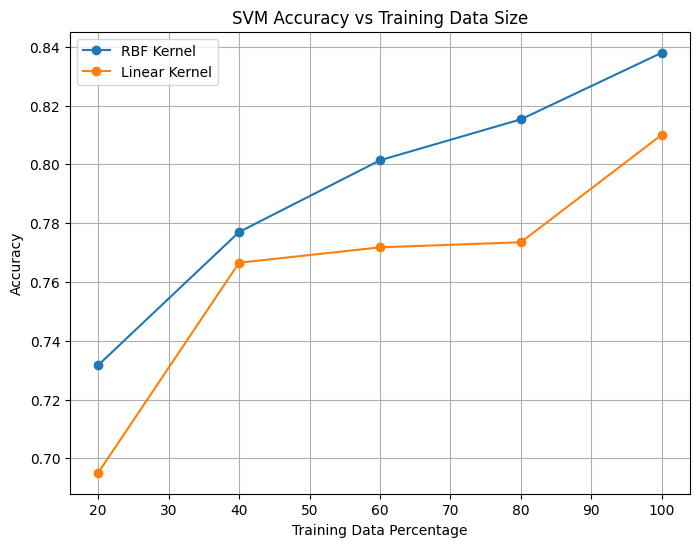

In [15]:
# =========================
# ACCURACY PLOT
# =========================

plt.figure(figsize=(8,6))

plt.plot(
    [20,40,60,80, 100],
    rbf_accuracy,
    marker='o',
    label='RBF Kernel'
)

plt.plot(
    [20,40,60,80, 100],
    linear_accuracy,
    marker='o',
    label='Linear Kernel'
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("SVM Accuracy vs Training Data Size")

plt.legend()

plt.grid(True)

plt.show()

# 